# Manual Linear Regression — Baseline
**Airbnb Price Prediction | DS4420 Final Project | Meixu Chen, Yuetong Yin**

This notebook implements OLS linear regression **from scratch using only NumPy**.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 

SEED = 42
np.random.seed(SEED)

## 1. Load & clean data

In [2]:
df = pd.read_csv('nyc_listings.csv', low_memory=False)

cols = [
    'price', 'accommodates', 'bedrooms', 'bathrooms_text',
    'room_type', 'property_type', 'minimum_nights',
    'number_of_reviews', 'review_scores_rating', 'host_is_superhost'
]
data = df[cols].copy()

# Clean price: strip '$' and ',' then cast to float
data['price'] = pd.to_numeric(
    data['price'].astype(str).str.replace(r'[\$,]', '', regex=True).str.strip(),
    errors='coerce'
)

# Extract numeric bathroom count from text like '1 bath', '1.5 baths'
data['bathrooms'] = pd.to_numeric(
    data['bathrooms_text'].str.extract(r'(\d+\.?\d*)')[0],
    errors='coerce'
)
data = data.drop(columns='bathrooms_text')

# Remove missing / invalid prices
data = data[
    data['price'].notna() &
    (data['price'] > 0) &
    (data['price'] < data['price'].quantile(0.97))
]


pt_counts = data['property_type'].value_counts()
data['property_type'] = data['property_type'].where(
    data['property_type'].isin(pt_counts[pt_counts >= 5].index), 'Other'
)

# Fill remaining nulls
data = data.assign(
    review_scores_rating=data['review_scores_rating'].fillna(data['review_scores_rating'].median()),
    host_is_superhost=data['host_is_superhost'].fillna('f'),
    bathrooms=data['bathrooms'].fillna(data['bathrooms'].median()),
    bedrooms=data['bedrooms'].fillna(data['bedrooms'].median()),
    # use log_transform to reduce right skew
    log_price=np.log(data['price'])  
)

print(f'Clean dataset: {data.shape[0]} listings, {data.isnull().sum().sum()} nulls remaining')
print(f'Price range: ${data["price"].min()} to ${data["price"].max()}, median ${data["price"].median()}')

Clean dataset: 20772 listings, 0 nulls remaining
Price range: $9.0 to $815.0, median $150.0


## 2. Exploratory plots

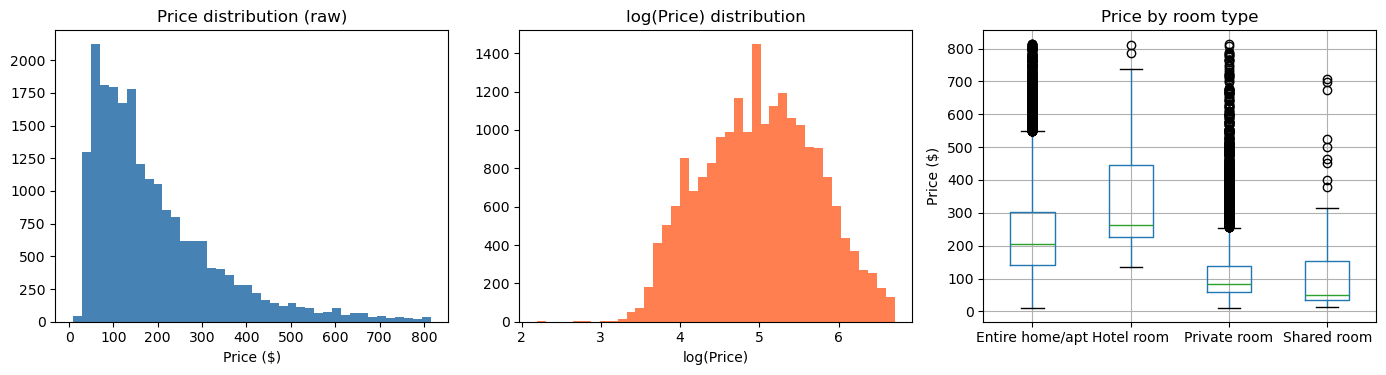

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(data['price'], bins=40, color='steelblue', edgecolor='none')
axes[0].set(title='Price distribution (raw)', xlabel='Price ($)')

axes[1].hist(data['log_price'], bins=40, color='coral', edgecolor='none')
axes[1].set(title='log(Price) distribution', xlabel='log(Price)')

data.boxplot(column='price', by='room_type', ax=axes[2])
axes[2].set(title='Price by room type', xlabel='', ylabel='Price ($)')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 3. Train / val / test split (70 / 15 / 15)

In [4]:
train, temp = train_test_split(data, test_size=0.30, random_state=SEED)
val, test   = train_test_split(temp, test_size=0.50, random_state=SEED)
print(f'Train: {len(train)}, Val: {len(val)}, Test: {len(test)}')

Train: 14540, Val: 3116, Test: 3116


## 4. Build design matrix (manual, no sklearn)

In [5]:
NUM_FEATS = ['accommodates', 'bedrooms', 'bathrooms', 'minimum_nights',
             'number_of_reviews', 'review_scores_rating']
CAT_FEATS = ['room_type', 'property_type', 'host_is_superhost']
TARGET    = 'log_price'

def build_X(df_split, num_feats, cat_feats,
            ohe_cols=None, means=None, stds=None):
    """
    Build design matrix manually.
    ohe_cols / means / stds: pass from training set when transforming val/test
    """
    # One-hot encode (pandas get_dummies, drop first to avoid multicollinearity)
    dummies = pd.get_dummies(df_split[cat_feats], drop_first=True)

    if ohe_cols is None:  # first call: remember training columns
        ohe_cols = dummies.columns.tolist()
    else:                 # subsequent calls: align to training columns
        dummies = dummies.reindex(columns=ohe_cols, fill_value=0)

    X_num = df_split[num_feats].values.astype(float)

    if means is None:  # compute stats from training data
        means = X_num.mean(axis=0)
        stds  = X_num.std(axis=0) + 1e-8

    X_num_scaled = (X_num - means) / stds
    bias = np.ones((len(df_split), 1))

    X = np.hstack([bias, X_num_scaled, dummies.values.astype(float)])
    return X, ohe_cols, means, stds


X_train, ohe_cols, means, stds = build_X(train, NUM_FEATS, CAT_FEATS)
X_val,   *_                    = build_X(val,   NUM_FEATS, CAT_FEATS, ohe_cols, means, stds)
X_test,  *_                    = build_X(test,  NUM_FEATS, CAT_FEATS, ohe_cols, means, stds)

y_train = train[TARGET].values
y_val   = val[TARGET].values
y_test  = test[TARGET].values

print(f'Design matrix shape: {X_train.shape}')

Design matrix shape: (14540, 49)


## 5. Fit OLS — closed-form solution

In [6]:
def ols_fit(X, y):
    """Closed-form OLS. Returns coefficient vector beta."""
    return np.linalg.pinv(X.T @ X) @ X.T @ y

beta = ols_fit(X_train, y_train)
print(f'Fitted {len(beta)} coefficients')

Fitted 49 coefficients


## 6. Evaluate on all splits

In [7]:
def evaluate(X, y, beta, label=''):
    y_pred    = X @ beta
    residuals = y - y_pred
    mae  = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals**2))
    r2   = 1 - np.sum(residuals**2) / np.sum((y - y.mean())**2)
    
    # Convert back to price scale for interpretability
    mae_price  = np.mean(np.abs(np.exp(y) - np.exp(y_pred)))
    rmse_price = np.sqrt(np.mean((np.exp(y) - np.exp(y_pred))**2))
    print(f'[{label}]  log-scale: MAE={mae:.4f}  RMSE={rmse:.4f}  R squre={r2:.4f}')
    print(f'          price-scale: MAE={mae_price:.2f}  RMSE={rmse_price:.2f}')
    return dict(label=label, mae=mae, rmse=rmse, r2=r2,
                mae_price=mae_price, rmse_price=rmse_price, y_pred=y_pred)

train_res = evaluate(X_train, y_train, beta, 'Train')
val_res   = evaluate(X_val,   y_val,   beta, 'Val')
test_res  = evaluate(X_test,  y_test,  beta, 'Test')

[Train]  log-scale: MAE=0.4008  RMSE=0.5025  R squre=0.5073
          price-scale: MAE=74.47  RMSE=113.63
[Val]  log-scale: MAE=0.4026  RMSE=0.5052  R squre=0.5085
          price-scale: MAE=75.69  RMSE=116.82
[Test]  log-scale: MAE=0.3968  RMSE=0.4951  R squre=0.5045
          price-scale: MAE=72.40  RMSE=110.31


## 7. Coefficient interpretation

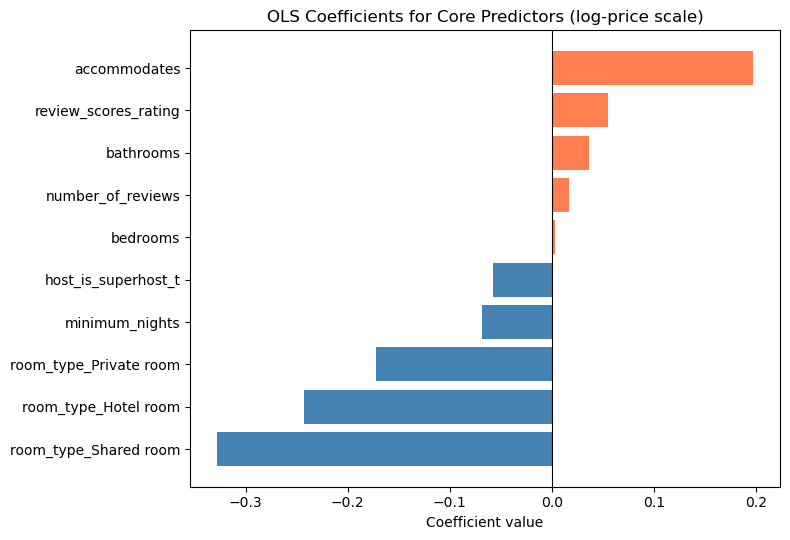

In [8]:
feature_names = ['bias'] + NUM_FEATS + ohe_cols
coef_df = pd.DataFrame({'feature': feature_names, 'coef': beta})

# exclude intercept
coef_df = coef_df[coef_df['feature'] != 'bias'].copy()

# remove property_type dummies for a cleaner interpretation plot
coef_plot_df = coef_df[~coef_df['feature'].str.startswith('property_type_')].copy()

# sort for horizontal bar plot
coef_plot_df = coef_plot_df.sort_values('coef', ascending=True)

colors = ['coral' if c > 0 else 'steelblue' for c in coef_plot_df['coef']]

plt.figure(figsize=(8, 5.5))
plt.barh(coef_plot_df['feature'], coef_plot_df['coef'], color=colors)
plt.axvline(0, color='black', lw=0.8)
plt.title('OLS Coefficients for Core Predictors (log-price scale)')
plt.xlabel('Coefficient value')
plt.tight_layout()
plt.show()

## 8. Residual analysis

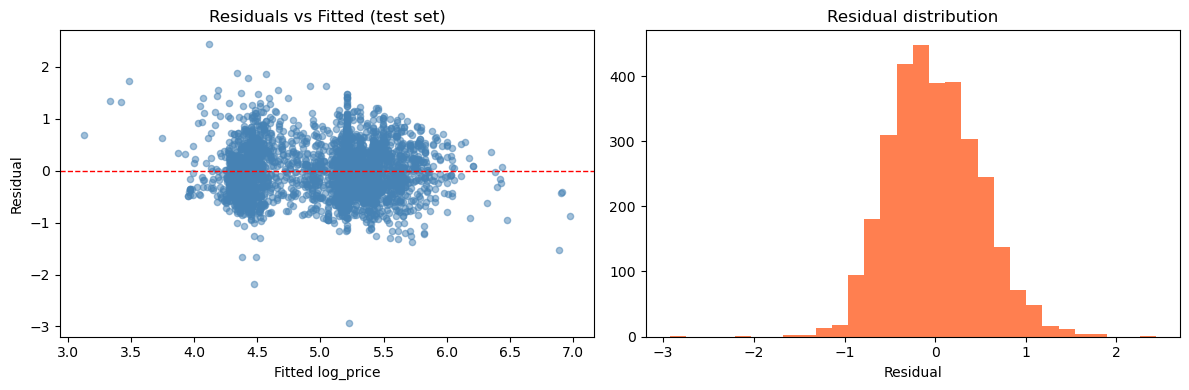

In [9]:
y_pred_test = X_test @ beta
residuals   = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_test, residuals, alpha=0.5, s=20, color='steelblue')
axes[0].axhline(0, color='red', lw=1, ls='--')
axes[0].set(title='Residuals vs Fitted (test set)',
            xlabel='Fitted log_price', ylabel='Residual')

axes[1].hist(residuals, bins=30, color='coral', edgecolor='none')
axes[1].set(title='Residual distribution', xlabel='Residual')

plt.tight_layout()
plt.show()

### 8.1 OLS: Actual vs Predicted (Log Scale)

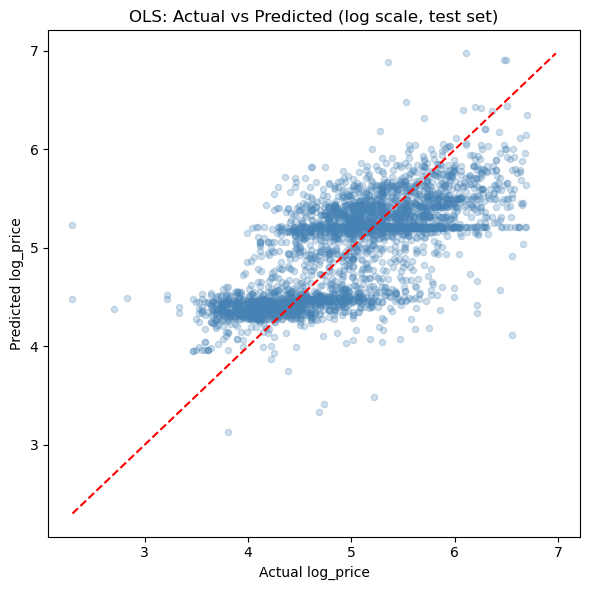

In [10]:
# Actual vs Predicted (log scale, test set)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, test_res['y_pred'], alpha=0.25, s=20, color='steelblue')

low = min(y_test.min(), test_res['y_pred'].min())
high = max(y_test.max(), test_res['y_pred'].max())
plt.plot([low, high], [low, high], linestyle='--', color='red')

plt.xlabel('Actual log_price')
plt.ylabel('Predicted log_price')
plt.title('OLS: Actual vs Predicted (log scale, test set)')
plt.tight_layout()
plt.show()

### 8.2 OLS: Actual vs Predicted (Price Scale)

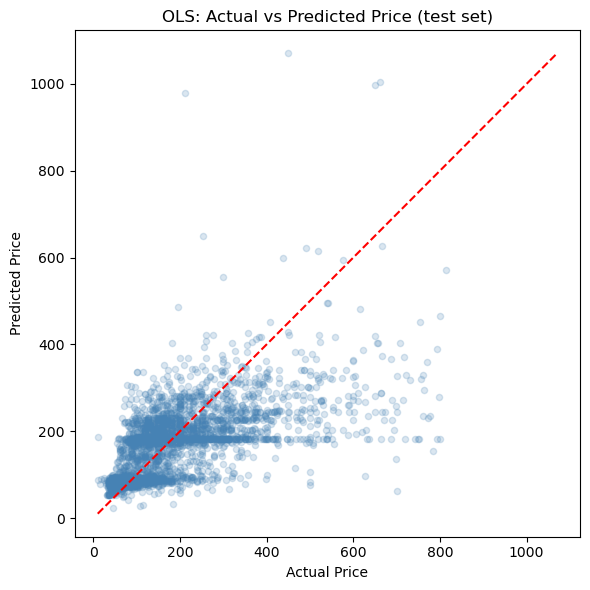

In [11]:
# Actual vs Predicted (price scale, test set)
actual_price = np.exp(y_test)
pred_price = np.exp(test_res['y_pred'])

plt.figure(figsize=(6, 6))
plt.scatter(actual_price, pred_price, alpha=0.2, s=20, color='steelblue')

low = min(actual_price.min(), pred_price.min())
high = max(actual_price.max(), pred_price.max())
plt.plot([low, high], [low, high], linestyle='--', color='red')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('OLS: Actual vs Predicted Price (test set)')
plt.tight_layout()
plt.show()

### 8.3 OLS: Actual vs Predicted (Price Scale, 95th Percentile)

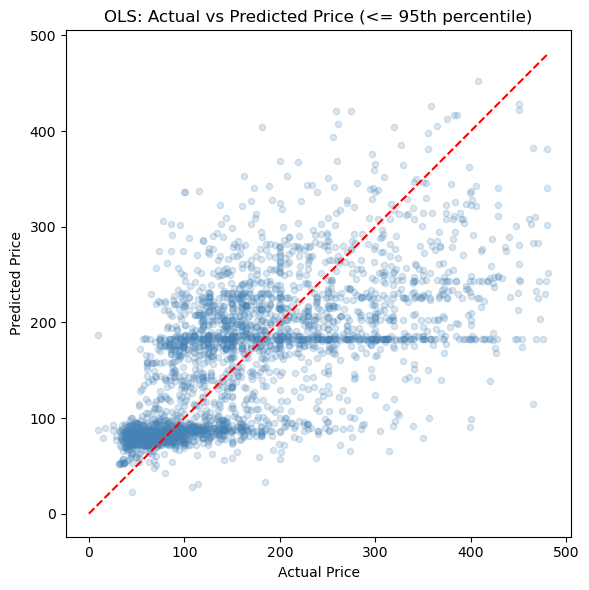

In [12]:
# Actual vs Predicted 
actual_price = np.exp(y_test)
pred_price = np.exp(test_res['y_pred'])

cutoff = np.quantile(actual_price, 0.95)
mask = (actual_price <= cutoff) & (pred_price <= cutoff)

plt.figure(figsize=(6, 6))
plt.scatter(actual_price[mask], pred_price[mask], alpha=0.2, s=20, color='steelblue')
plt.plot([0, cutoff], [0, cutoff], linestyle='--', color='red')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('OLS: Actual vs Predicted Price (<= 95th percentile)')
plt.tight_layout()
plt.show()

## 9. Summary metrics (for final paper comparison table)

In [13]:
print('OLS Baseline — Test Set Results')
print(f"  MAE  (log scale):   {test_res['mae']:.4f}")
print(f"  RMSE (log scale):   {test_res['rmse']:.4f}")
print(f"  R squre:            {test_res['r2']:.4f}")
print(f"  MAE  (price scale): ${test_res['mae_price']:.2f}")
print(f"  RMSE (price scale): ${test_res['rmse_price']:.2f}")

OLS Baseline — Test Set Results
  MAE  (log scale):   0.3968
  RMSE (log scale):   0.4951
  R squre:            0.5045
  MAE  (price scale): $72.40
  RMSE (price scale): $110.31


In [14]:
bayes_df = data.copy()

bayes_df["split"] = "train"
bayes_df.loc[val.index, "split"] = "validation"
bayes_df.loc[test.index, "split"] = "test"

bayes_df.to_csv("bayesian_model_data.csv", index=False)

In [15]:
bayes_df["split"].value_counts()

split
train         14540
test           3116
validation     3116
Name: count, dtype: int64